Clerk automatically sends a `clerk/user.created` event to your Inngest endpoint. This webhook is configured in the Clerk dashboard under **Developers → Webhooks**.

### Step 3: Inngest Receives and Extracts the Data

The `syncUser` function in `backend/src/config/inggest.js` listens for this event and runs automatically:




In [ ]:
export const syncUser = inngest.createFunction(
    {
        id: "sync-user",
        triggers: [{ event: "clerk/user.created" }],  // ← Listening for this event
    },

    async ({ event }) => {
        await connectDB();  // Connect to MongoDB

        // Inngest automatically passes the Clerk webhook data in event.data
        const {
            id,                 // Clerk user ID
            email_addresses,    // Array of email objects
            first_name,
            last_name,
            image_url,
        } = event.data;

        // Create the new user record in your MongoDB
        const newUser = {
            clerkId: id,                                    // Link to Clerk
            email: email_addresses[0]?.email_address,       // Extract first email
            name: `${first_name || ""} ${last_name || ""}` || "User",
            imageUrl: image_url,
            addresses: [],  // Empty at first, user adds later
            wishlist: [],   // Empty at first
        };

        await User.create(newUser);  // Save to MongoDB
    }
);


### Step 4: Data Appears in MongoDB

Once the function runs, the user is saved with these fields (from `backend/src/models/user.model.js`):
- `email` — user contact
- `name` — display name
- `imageURL` — profile picture
- `clerkId` — linked to Clerk account
- `addresses` — empty array for now, user adds later
- `wishlist` — empty array for now
- `createdAt` and `updatedAt` — timestamps

### Data Mapping

From the Clerk webhook, Inngest extracts and transforms:

| Clerk field | Stored in MongoDB as | Used for |
|---|---|---|
| `id` | `clerkId` | Link to Clerk account |
| `email_addresses[0].email_address` | `email` | User contact |
| `first_name` + `last_name` | `name` | Display name |
| `image_url` | `imageUrl` | Profile picture |

### If the Sync Doesn't Happen

Check these items:

1. **Clerk webhook configured?** Go to **Developers → Webhooks** in the Clerk dashboard and verify the endpoint is connected
2. **Inngest signing key set?** Make sure `INNGEST_SIGNING_KEY` is in `backend/.env`
3. **MongoDB connection?** Verify `DB_URL` is correct in `backend/.env`
4. **Backend endpoint registered?** The backend exposes `/api/inngest` for webhooks (see `backend/src/server.js`)
5. **Correct events subscribed?** Make sure you subscribed to `User Created` and `User Deleted` in the Clerk webhook

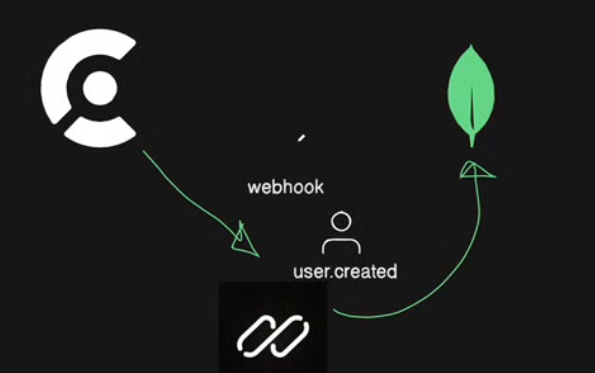